In [2]:
!pip install pandas numpy matplotlib seaborn mlxtend openpyxl
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")


   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   --------------- ------------------------ 0.5/1.4 MB 8.7 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 4.2 MB/s  0:00:00

   ---------------------------------------- 0/2 [seaborn]
   ---------------------------------------- 0/2 [seaborn]
   ---------------------------------------- 0/2 [seaborn]
   ---------------------------------------- 0/2 [seaborn]
   ---------------------------------------- 0/2 [seaborn]
   ---------------------------------------- 0/2 [seaborn]
   -------------------- ------------------- 1/2 [mlxtend]
   -------------------- ------------------- 1/2 [mlxtend]
   -------------------- ------------------- 1/2 [mlxtend]
   -------------------- ------------------- 1/2 [mlxtend]
   -------------------- ------------------- 1/2 [mlxtend]
   -------------------- ------------------- 1/2 [mlxtend]
   -------------------- ------------------- 1/2 [mlxtend]
   -------------------- ---


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Libraries imported successfully!


# Shopping Basket Analysis using Apriori Algorithm

## Objective
The objective of this project is to analyze customers' purchasing patterns and identify products that are frequently bought together using the Apriori algorithm.

## Step 1: Import Required Libraries

In [7]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

## Step 2: Load the Dataset

In [8]:
# Load the dataset
import pandas as pd

df = pd.read_csv("Groceries_dataset.csv")

# Display first five rows
df.head()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


## Step 3: Explore the Dataset

In [9]:
# Shape of the dataset
print("Shape of the dataset:", df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns)

# Dataset information
print("\nDataset Information:")
df.info()

Shape of the dataset: (38765, 3)

Column Names:
Index(['Member_number', 'Date', 'itemDescription'], dtype='str')

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Member_number    38765 non-null  int64
 1   Date             38765 non-null  str  
 2   itemDescription  38765 non-null  str  
dtypes: int64(1), str(2)
memory usage: 908.7 KB


In [10]:
# Check for missing values
print(df.isnull().sum())

Member_number      0
Date               0
itemDescription    0
dtype: int64


In [11]:
# Number of unique customers
print("Unique Customers:", df['Member_number'].nunique())

# Number of unique products
print("Unique Products:", df['itemDescription'].nunique())

Unique Customers: 3898
Unique Products: 167


In [12]:
# Display top 10 most purchased items
df['itemDescription'].value_counts().head(10)

itemDescription
whole milk          2502
other vegetables    1898
rolls/buns          1716
soda                1514
yogurt              1334
root vegetables     1071
tropical fruit      1032
bottled water        933
sausage              924
citrus fruit         812
Name: count, dtype: int64

## Step 4: Data Cleaning

In [13]:
# Check duplicate rows

duplicates = df.duplicated().sum()

print("Number of duplicate records:", duplicates)

Number of duplicate records: 759


In [14]:
# Remove duplicate rows

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (38006, 3)


In [16]:
# Convert Date column to datetime format

df['Date'] = pd.to_datetime(df['Date'])

df.info()
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

<class 'pandas.DataFrame'>
Index: 38006 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Member_number    38006 non-null  int64         
 1   Date             38006 non-null  datetime64[us]
 2   itemDescription  38006 non-null  str           
dtypes: datetime64[us](1), int64(1), str(1)
memory usage: 1.2 MB


## Step 5: Data Visualization

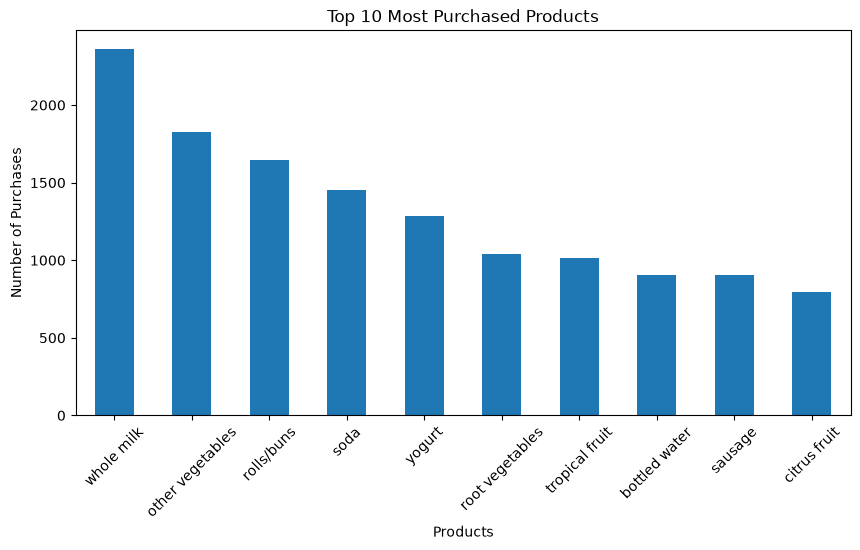

In [17]:
import matplotlib.pyplot as plt

top_products = df['itemDescription'].value_counts().head(10)

plt.figure(figsize=(10,5))

top_products.plot(kind='bar')

plt.title("Top 10 Most Purchased Products")
plt.xlabel("Products")
plt.ylabel("Number of Purchases")

plt.xticks(rotation=45)

plt.show()

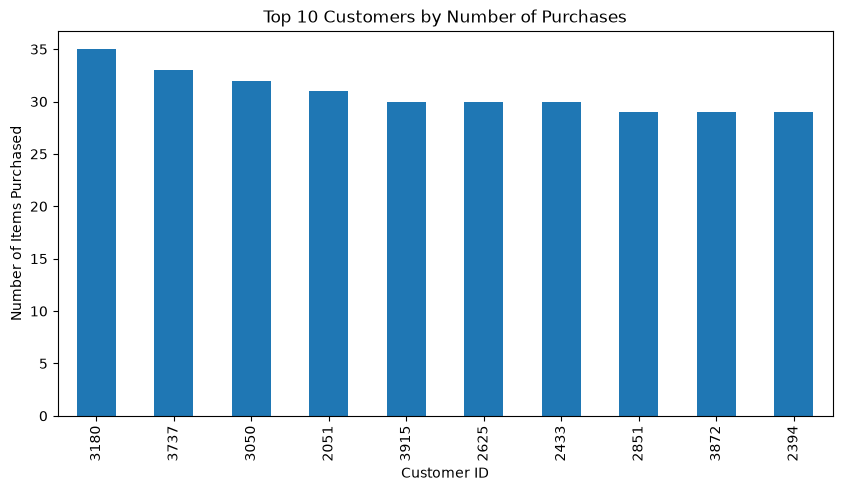

In [18]:
top_customers = df['Member_number'].value_counts().head(10)

plt.figure(figsize=(10,5))

top_customers.plot(kind='bar')

plt.title("Top 10 Customers by Number of Purchases")

plt.xlabel("Customer ID")

plt.ylabel("Number of Items Purchased")

plt.show()

## Step 6: Transaction Transformation

In [19]:
# Group products purchased by each customer on each date

transactions = df.groupby(
    ['Member_number', 'Date']
)['itemDescription'].apply(list)

transactions.head()

Member_number  Date      
1000           2014-06-24                    [whole milk, pastry, salty snack]
               2015-03-15    [sausage, whole milk, semi-finished bread, yog...
               2015-05-27                           [soda, pickled vegetables]
               2015-07-24                       [canned beer, misc. beverages]
               2015-11-25                          [sausage, hygiene articles]
Name: itemDescription, dtype: object

In [20]:
print("Total Transactions:", len(transactions))

Total Transactions: 14963


In [21]:
transaction_list = transactions.tolist()

transaction_list[:5]

[['whole milk', 'pastry', 'salty snack'],
 ['sausage', 'whole milk', 'semi-finished bread', 'yogurt'],
 ['soda', 'pickled vegetables'],
 ['canned beer', 'misc. beverages'],
 ['sausage', 'hygiene articles']]

In [22]:
from mlxtend.preprocessing import TransactionEncoder

encoder = TransactionEncoder()

encoded_data = encoder.fit(transaction_list).transform(transaction_list)

basket = pd.DataFrame(
    encoded_data,
    columns=encoder.columns_
)

basket.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [23]:
len(transaction_list)

14963

In [24]:
basket.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Step 7: Apriori Algorithm

In [25]:
from mlxtend.frequent_patterns import apriori

In [26]:
frequent_itemsets = apriori(
    basket,
    min_support=0.01,
    use_colnames=True
)

frequent_itemsets.head()

,support,itemsets
0,0.021386,frozenset({UHT-milk})
1,0.033950,frozenset({beef})
2,0.021787,frozenset({berries})
3,0.016574,frozenset({beverages})
4,0.045312,frozenset({bottled beer})


In [27]:
frequent_itemsets.head()

,support,itemsets
0,0.021386,frozenset({UHT-milk})
1,0.033950,frozenset({beef})
2,0.021787,frozenset({berries})
3,0.016574,frozenset({beverages})
4,0.045312,frozenset({bottled beer})


In [28]:
print("Total Frequent Itemsets:", len(frequent_itemsets))

Total Frequent Itemsets: 69


In [29]:
frequent_itemsets.sort_values(
    by='support',
    ascending=False
).head(10)

,support,itemsets
62,0.157923,frozenset({whole milk})
40,0.122101,frozenset({other vegetables})
46,0.110005,frozenset({rolls/buns})
52,0.097106,frozenset({soda})
63,0.085879,frozenset({yogurt})
47,0.069572,frozenset({root vegetables})
57,0.067767,frozenset({tropical fruit})
5,0.060683,frozenset({bottled water})
49,0.060349,frozenset({sausage})
15,0.053131,frozenset({citrus fruit})


In [30]:
frequent_itemsets = apriori(
    basket,
    min_support=0.005,
    use_colnames=True
)

frequent_itemsets[
    frequent_itemsets['itemsets'].apply(lambda x: len(x) > 1)
].head(10)

,support,itemsets
89,0.007151,"frozenset({bottled beer, whole milk})"
90,0.005480,"frozenset({other vegetables, bottled water})"
91,0.007151,"frozenset({bottled water, whole milk})"
92,0.006015,"frozenset({canned beer, whole milk})"
93,0.007151,"frozenset({citrus fruit, whole milk})"
94,0.005280,"frozenset({domestic eggs, whole milk})"
95,0.005146,"frozenset({other vegetables, frankfurter})"
96,0.005280,"frozenset({frankfurter, whole milk})"
97,0.005614,"frozenset({newspapers, whole milk})"
98,0.010559,"frozenset({other vegetables, rolls/buns})"


In [32]:
print("Total Frequent Itemsets:", len(frequent_itemsets))

Total Frequent Itemsets: 126


In [33]:
frequent_itemsets[
    frequent_itemsets['itemsets'].apply(lambda x: len(x) > 1)
].head(10)

,support,itemsets
89,0.007151,"frozenset({bottled beer, whole milk})"
90,0.005480,"frozenset({other vegetables, bottled water})"
91,0.007151,"frozenset({bottled water, whole milk})"
92,0.006015,"frozenset({canned beer, whole milk})"
93,0.007151,"frozenset({citrus fruit, whole milk})"
94,0.005280,"frozenset({domestic eggs, whole milk})"
95,0.005146,"frozenset({other vegetables, frankfurter})"
96,0.005280,"frozenset({frankfurter, whole milk})"
97,0.005614,"frozenset({newspapers, whole milk})"
98,0.010559,"frozenset({other vegetables, rolls/buns})"


In [34]:
from mlxtend.frequent_patterns import association_rules

In [35]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.1
)

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({bottled beer}),frozenset({whole milk}),0.045312,0.157923,0.007151,0.157817,0.999330,1.0,-0.000005,0.999874,-0.000702,0.036469,-0.000126,0.101549
1,frozenset({bottled water}),frozenset({whole milk}),0.060683,0.157923,0.007151,0.117841,0.746196,1.0,-0.002432,0.954564,-0.265842,0.033818,-0.047598,0.081561
2,frozenset({canned beer}),frozenset({whole milk}),0.046916,0.157923,0.006015,0.128205,0.811821,1.0,-0.001394,0.965912,-0.195630,0.030252,-0.035291,0.083146
3,frozenset({citrus fruit}),frozenset({whole milk}),0.053131,0.157923,0.007151,0.134591,0.852259,1.0,-0.001240,0.973040,-0.154748,0.035070,-0.027707,0.089936
4,frozenset({domestic eggs}),frozenset({whole milk}),0.037091,0.157923,0.005280,0.142342,0.901341,1.0,-0.000578,0.981834,-0.102072,0.027827,-0.018503,0.087887


In [36]:
rules[['antecedents',
       'consequents',
       'support',
       'confidence',
       'lift']].head()

,antecedents,consequents,support,confidence,lift
0,frozenset({bottled beer}),frozenset({whole milk}),0.007151,0.157817,0.999330
1,frozenset({bottled water}),frozenset({whole milk}),0.007151,0.117841,0.746196
2,frozenset({canned beer}),frozenset({whole milk}),0.006015,0.128205,0.811821
3,frozenset({citrus fruit}),frozenset({whole milk}),0.007151,0.134591,0.852259
4,frozenset({domestic eggs}),frozenset({whole milk}),0.005280,0.142342,0.901341


In [37]:
strong_rules = rules.sort_values(
    by='lift',
    ascending=False
)

strong_rules.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
5,frozenset({frankfurter}),frozenset({other vegetables}),0.037760,0.122101,0.005146,0.136283,1.116150,1.0,0.000536,1.016420,0.108146,0.033261,0.016154,0.089214
0,frozenset({bottled beer}),frozenset({whole milk}),0.045312,0.157923,0.007151,0.157817,0.999330,1.0,-0.000005,0.999874,-0.000702,0.036469,-0.000126,0.101549
14,frozenset({sausage}),frozenset({whole milk}),0.060349,0.157923,0.008955,0.148394,0.939663,1.0,-0.000575,0.988811,-0.063965,0.042784,-0.011316,0.102551
7,frozenset({newspapers}),frozenset({whole milk}),0.038896,0.157923,0.005614,0.144330,0.913926,1.0,-0.000529,0.984114,-0.089246,0.029360,-0.016142,0.089939
4,frozenset({domestic eggs}),frozenset({whole milk}),0.037091,0.157923,0.005280,0.142342,0.901341,1.0,-0.000578,0.981834,-0.102072,0.027827,-0.018503,0.087887
6,frozenset({frankfurter}),frozenset({whole milk}),0.037760,0.157923,0.005280,0.139823,0.885388,1.0,-0.000683,0.978958,-0.118576,0.027729,-0.021494,0.086628
11,frozenset({pork}),frozenset({whole milk}),0.037091,0.157923,0.005012,0.135135,0.855703,1.0,-0.000845,0.973652,-0.149027,0.026381,-0.027061,0.083437
10,frozenset({pip fruit}),frozenset({whole milk}),0.049054,0.157923,0.006616,0.134877,0.854071,1.0,-0.001130,0.973362,-0.152310,0.033022,-0.027367,0.088387
3,frozenset({citrus fruit}),frozenset({whole milk}),0.053131,0.157923,0.007151,0.134591,0.852259,1.0,-0.001240,0.973040,-0.154748,0.035070,-0.027707,0.089936
15,frozenset({shopping bags}),frozenset({whole milk}),0.047584,0.157923,0.006349,0.133427,0.844887,1.0,-0.001166,0.971732,-0.161610,0.031879,-0.029090,0.086815


In [38]:
strong_rules.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
5,frozenset({frankfurter}),frozenset({other vegetables}),0.037760,0.122101,0.005146,0.136283,1.116150,1.0,0.000536,1.016420,0.108146,0.033261,0.016154,0.089214
0,frozenset({bottled beer}),frozenset({whole milk}),0.045312,0.157923,0.007151,0.157817,0.999330,1.0,-0.000005,0.999874,-0.000702,0.036469,-0.000126,0.101549
14,frozenset({sausage}),frozenset({whole milk}),0.060349,0.157923,0.008955,0.148394,0.939663,1.0,-0.000575,0.988811,-0.063965,0.042784,-0.011316,0.102551
7,frozenset({newspapers}),frozenset({whole milk}),0.038896,0.157923,0.005614,0.144330,0.913926,1.0,-0.000529,0.984114,-0.089246,0.029360,-0.016142,0.089939
4,frozenset({domestic eggs}),frozenset({whole milk}),0.037091,0.157923,0.005280,0.142342,0.901341,1.0,-0.000578,0.981834,-0.102072,0.027827,-0.018503,0.087887
6,frozenset({frankfurter}),frozenset({whole milk}),0.037760,0.157923,0.005280,0.139823,0.885388,1.0,-0.000683,0.978958,-0.118576,0.027729,-0.021494,0.086628
11,frozenset({pork}),frozenset({whole milk}),0.037091,0.157923,0.005012,0.135135,0.855703,1.0,-0.000845,0.973652,-0.149027,0.026381,-0.027061,0.083437
10,frozenset({pip fruit}),frozenset({whole milk}),0.049054,0.157923,0.006616,0.134877,0.854071,1.0,-0.001130,0.973362,-0.152310,0.033022,-0.027367,0.088387
3,frozenset({citrus fruit}),frozenset({whole milk}),0.053131,0.157923,0.007151,0.134591,0.852259,1.0,-0.001240,0.973040,-0.154748,0.035070,-0.027707,0.089936
15,frozenset({shopping bags}),frozenset({whole milk}),0.047584,0.157923,0.006349,0.133427,0.844887,1.0,-0.001166,0.971732,-0.161610,0.031879,-0.029090,0.086815


In [39]:
strong_rules = rules[
    (rules['confidence'] >= 0.3) &
    (rules['lift'] > 1)
]

strong_rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


In [40]:
strong_rules = strong_rules.sort_values(
    by='lift',
    ascending=False
)

strong_rules.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


In [41]:
strong_rules.shape

(0, 14)

In [42]:
strong_rules.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


In [43]:
rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1
)

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({other vegetables}),frozenset({frankfurter}),0.122101,0.037760,0.005146,0.042146,1.116150,1.0,0.000536,1.004579,0.118536,0.033261,0.004558,0.089214
1,frozenset({frankfurter}),frozenset({other vegetables}),0.037760,0.122101,0.005146,0.136283,1.116150,1.0,0.000536,1.016420,0.108146,0.033261,0.016154,0.089214
2,frozenset({sausage}),frozenset({soda}),0.060349,0.097106,0.005948,0.098560,1.014975,1.0,0.000088,1.001613,0.015702,0.039259,0.001611,0.079906
3,frozenset({soda}),frozenset({sausage}),0.097106,0.060349,0.005948,0.061253,1.014975,1.0,0.000088,1.000963,0.016341,0.039259,0.000962,0.079906
4,frozenset({yogurt}),frozenset({sausage}),0.085879,0.060349,0.005748,0.066926,1.108986,1.0,0.000565,1.007049,0.107508,0.040913,0.007000,0.081082


In [44]:
strong_rules = rules[
    (rules['lift'] > 1) &
    (rules['confidence'] >= 0.15)
]

strong_rules = strong_rules.sort_values(
    by='lift',
    ascending=False
)

strong_rules.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


In [45]:
strong_rules.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


In [46]:
strong_rules.shape

(0, 14)

In [47]:
rules.shape

(6, 14)

In [48]:
rules.sort_values(
    by='lift',
    ascending=False
).head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1,frozenset({frankfurter}),frozenset({other vegetables}),0.037760,0.122101,0.005146,0.136283,1.116150,1.0,0.000536,1.016420,0.108146,0.033261,0.016154,0.089214
0,frozenset({other vegetables}),frozenset({frankfurter}),0.122101,0.037760,0.005146,0.042146,1.116150,1.0,0.000536,1.004579,0.118536,0.033261,0.004558,0.089214
5,frozenset({sausage}),frozenset({yogurt}),0.060349,0.085879,0.005748,0.095238,1.108986,1.0,0.000565,1.010345,0.104587,0.040913,0.010239,0.081082
4,frozenset({yogurt}),frozenset({sausage}),0.085879,0.060349,0.005748,0.066926,1.108986,1.0,0.000565,1.007049,0.107508,0.040913,0.007000,0.081082
3,frozenset({soda}),frozenset({sausage}),0.097106,0.060349,0.005948,0.061253,1.014975,1.0,0.000088,1.000963,0.016341,0.039259,0.000962,0.079906
2,frozenset({sausage}),frozenset({soda}),0.060349,0.097106,0.005948,0.098560,1.014975,1.0,0.000088,1.001613,0.015702,0.039259,0.001611,0.079906


In [49]:
rules = association_rules(
    frequent_itemsets,
    metric="support",
    min_threshold=0.005
)

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,frozenset({bottled beer}),frozenset({whole milk}),0.045312,0.157923,0.007151,0.157817,0.999330,1.0,-0.000005,0.999874,-0.000702,0.036469,-0.000126,0.101549
1,frozenset({whole milk}),frozenset({bottled beer}),0.157923,0.045312,0.007151,0.045281,0.999330,1.0,-0.000005,0.999968,-0.000795,0.036469,-0.000032,0.101549
2,frozenset({other vegetables}),frozenset({bottled water}),0.122101,0.060683,0.005480,0.044882,0.739619,1.0,-0.001929,0.983457,-0.286230,0.030908,-0.016821,0.067595
3,frozenset({bottled water}),frozenset({other vegetables}),0.060683,0.122101,0.005480,0.090308,0.739619,1.0,-0.001929,0.965051,-0.272617,0.030908,-0.036215,0.067595
4,frozenset({bottled water}),frozenset({whole milk}),0.060683,0.157923,0.007151,0.117841,0.746196,1.0,-0.002432,0.954564,-0.265842,0.033818,-0.047598,0.081561


In [50]:
rules.sort_values(
    by='lift',
    ascending=False
).head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
13,frozenset({frankfurter}),frozenset({other vegetables}),0.037760,0.122101,0.005146,0.136283,1.116150,1.0,0.000536,1.016420,0.108146,0.033261,0.016154,0.089214
12,frozenset({other vegetables}),frozenset({frankfurter}),0.122101,0.037760,0.005146,0.042146,1.116150,1.0,0.000536,1.004579,0.118536,0.033261,0.004558,0.089214
59,frozenset({sausage}),frozenset({yogurt}),0.060349,0.085879,0.005748,0.095238,1.108986,1.0,0.000565,1.010345,0.104587,0.040913,0.010239,0.081082
58,frozenset({yogurt}),frozenset({sausage}),0.085879,0.060349,0.005748,0.066926,1.108986,1.0,0.000565,1.007049,0.107508,0.040913,0.007000,0.081082
54,frozenset({sausage}),frozenset({soda}),0.060349,0.097106,0.005948,0.098560,1.014975,1.0,0.000088,1.001613,0.015702,0.039259,0.001611,0.079906
55,frozenset({soda}),frozenset({sausage}),0.097106,0.060349,0.005948,0.061253,1.014975,1.0,0.000088,1.000963,0.016341,0.039259,0.000962,0.079906
0,frozenset({bottled beer}),frozenset({whole milk}),0.045312,0.157923,0.007151,0.157817,0.999330,1.0,-0.000005,0.999874,-0.000702,0.036469,-0.000126,0.101549
1,frozenset({whole milk}),frozenset({bottled beer}),0.157923,0.045312,0.007151,0.045281,0.999330,1.0,-0.000005,0.999968,-0.000795,0.036469,-0.000032,0.101549
56,frozenset({sausage}),frozenset({whole milk}),0.060349,0.157923,0.008955,0.148394,0.939663,1.0,-0.000575,0.988811,-0.063965,0.042784,-0.011316,0.102551
57,frozenset({whole milk}),frozenset({sausage}),0.157923,0.060349,0.008955,0.056708,0.939663,1.0,-0.000575,0.996140,-0.070851,0.042784,-0.003875,0.102551


In [51]:
rules.shape

(74, 14)

In [52]:
rules.sort_values(by='lift', ascending=False).head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
13,frozenset({frankfurter}),frozenset({other vegetables}),0.037760,0.122101,0.005146,0.136283,1.116150,1.0,0.000536,1.016420,0.108146,0.033261,0.016154,0.089214
12,frozenset({other vegetables}),frozenset({frankfurter}),0.122101,0.037760,0.005146,0.042146,1.116150,1.0,0.000536,1.004579,0.118536,0.033261,0.004558,0.089214
59,frozenset({sausage}),frozenset({yogurt}),0.060349,0.085879,0.005748,0.095238,1.108986,1.0,0.000565,1.010345,0.104587,0.040913,0.010239,0.081082
58,frozenset({yogurt}),frozenset({sausage}),0.085879,0.060349,0.005748,0.066926,1.108986,1.0,0.000565,1.007049,0.107508,0.040913,0.007000,0.081082
54,frozenset({sausage}),frozenset({soda}),0.060349,0.097106,0.005948,0.098560,1.014975,1.0,0.000088,1.001613,0.015702,0.039259,0.001611,0.079906
55,frozenset({soda}),frozenset({sausage}),0.097106,0.060349,0.005948,0.061253,1.014975,1.0,0.000088,1.000963,0.016341,0.039259,0.000962,0.079906
0,frozenset({bottled beer}),frozenset({whole milk}),0.045312,0.157923,0.007151,0.157817,0.999330,1.0,-0.000005,0.999874,-0.000702,0.036469,-0.000126,0.101549
1,frozenset({whole milk}),frozenset({bottled beer}),0.157923,0.045312,0.007151,0.045281,0.999330,1.0,-0.000005,0.999968,-0.000795,0.036469,-0.000032,0.101549
56,frozenset({sausage}),frozenset({whole milk}),0.060349,0.157923,0.008955,0.148394,0.939663,1.0,-0.000575,0.988811,-0.063965,0.042784,-0.011316,0.102551
57,frozenset({whole milk}),frozenset({sausage}),0.157923,0.060349,0.008955,0.056708,0.939663,1.0,-0.000575,0.996140,-0.070851,0.042784,-0.003875,0.102551


## Step 9: Association Rule Visualization

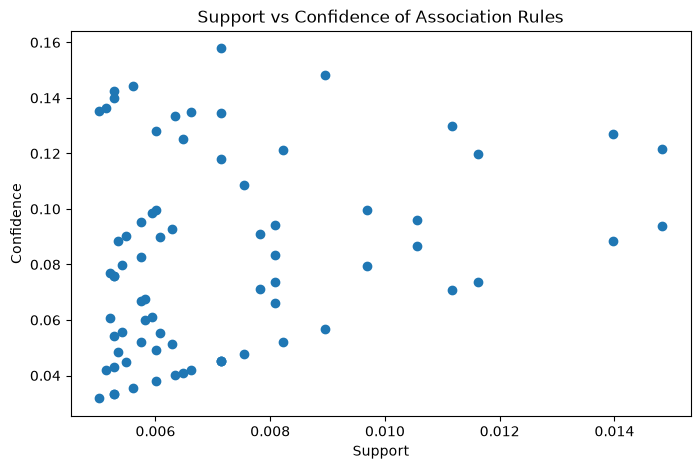

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    rules['support'],
    rules['confidence']
)

plt.xlabel("Support")
plt.ylabel("Confidence")

plt.title("Support vs Confidence of Association Rules")

plt.show()

In [54]:
top_rules = rules.sort_values(
    by='lift',
    ascending=False
).head(10)

top_rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
13,frozenset({frankfurter}),frozenset({other vegetables}),0.037760,0.122101,0.005146,0.136283,1.116150,1.0,0.000536,1.016420,0.108146,0.033261,0.016154,0.089214
12,frozenset({other vegetables}),frozenset({frankfurter}),0.122101,0.037760,0.005146,0.042146,1.116150,1.0,0.000536,1.004579,0.118536,0.033261,0.004558,0.089214
59,frozenset({sausage}),frozenset({yogurt}),0.060349,0.085879,0.005748,0.095238,1.108986,1.0,0.000565,1.010345,0.104587,0.040913,0.010239,0.081082
58,frozenset({yogurt}),frozenset({sausage}),0.085879,0.060349,0.005748,0.066926,1.108986,1.0,0.000565,1.007049,0.107508,0.040913,0.007000,0.081082
54,frozenset({sausage}),frozenset({soda}),0.060349,0.097106,0.005948,0.098560,1.014975,1.0,0.000088,1.001613,0.015702,0.039259,0.001611,0.079906
55,frozenset({soda}),frozenset({sausage}),0.097106,0.060349,0.005948,0.061253,1.014975,1.0,0.000088,1.000963,0.016341,0.039259,0.000962,0.079906
0,frozenset({bottled beer}),frozenset({whole milk}),0.045312,0.157923,0.007151,0.157817,0.999330,1.0,-0.000005,0.999874,-0.000702,0.036469,-0.000126,0.101549
1,frozenset({whole milk}),frozenset({bottled beer}),0.157923,0.045312,0.007151,0.045281,0.999330,1.0,-0.000005,0.999968,-0.000795,0.036469,-0.000032,0.101549
56,frozenset({sausage}),frozenset({whole milk}),0.060349,0.157923,0.008955,0.148394,0.939663,1.0,-0.000575,0.988811,-0.063965,0.042784,-0.011316,0.102551
57,frozenset({whole milk}),frozenset({sausage}),0.157923,0.060349,0.008955,0.056708,0.939663,1.0,-0.000575,0.996140,-0.070851,0.042784,-0.003875,0.102551


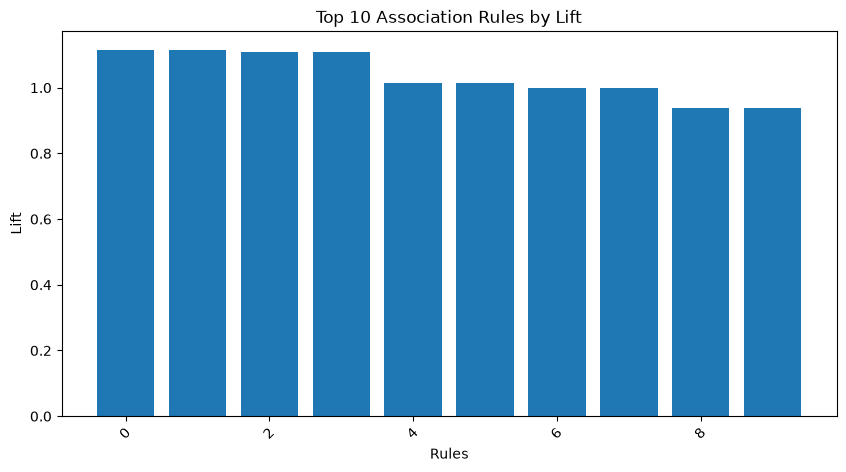

In [55]:
plt.figure(figsize=(10,5))

plt.bar(
    range(len(top_rules)),
    top_rules['lift']
)

plt.xlabel("Rules")
plt.ylabel("Lift")

plt.title("Top 10 Association Rules by Lift")

plt.xticks(rotation=45)

plt.show()

## Step 10: Business Insights

In [56]:
top_products = df['itemDescription'].value_counts().head(10)

top_products

itemDescription
whole milk          2363
other vegetables    1827
rolls/buns          1646
soda                1453
yogurt              1285
root vegetables     1041
tropical fruit      1014
bottled water        908
sausage              903
citrus fruit         795
Name: count, dtype: int64

In [57]:
best_rules = rules.sort_values(
    by='lift',
    ascending=False
).head(10)

best_rules[['antecedents',
            'consequents',
            'support',
            'confidence',
            'lift']]

,antecedents,consequents,support,confidence,lift
13,frozenset({frankfurter}),frozenset({other vegetables}),0.005146,0.136283,1.116150
12,frozenset({other vegetables}),frozenset({frankfurter}),0.005146,0.042146,1.116150
59,frozenset({sausage}),frozenset({yogurt}),0.005748,0.095238,1.108986
58,frozenset({yogurt}),frozenset({sausage}),0.005748,0.066926,1.108986
54,frozenset({sausage}),frozenset({soda}),0.005948,0.098560,1.014975
55,frozenset({soda}),frozenset({sausage}),0.005948,0.061253,1.014975
0,frozenset({bottled beer}),frozenset({whole milk}),0.007151,0.157817,0.999330
1,frozenset({whole milk}),frozenset({bottled beer}),0.007151,0.045281,0.999330
56,frozenset({sausage}),frozenset({whole milk}),0.008955,0.148394,0.939663
57,frozenset({whole milk}),frozenset({sausage}),0.008955,0.056708,0.939663


In [58]:
rules.to_csv(
    "association_rules.csv",
    index=False
)

print("Association rules saved successfully!")

Association rules saved successfully!


## Conclusion

This project analyzed grocery transaction data using Market Basket Analysis techniques. The dataset was cleaned and transformed into transaction format, followed by the application of the Apriori algorithm to identify frequent item combinations. Association rules were generated using support, confidence, and lift metrics to discover relationships between products. The results can help retailers improve product placement, create targeted promotions, and enhance customer recommendations.